# Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

INPUT_PATH  = '/kaggle/input/notebooks/hayeonchung353/ds-5001-final-project-notebook-1/'
INPUT_PATH2 = '/kaggle/input/notebooks/hayeonchung353/ds-5001-final-project-notebook-2/'
OUTPUT_PATH = '/kaggle/working/'

# From Notebook 1
LIB       = pd.read_csv(INPUT_PATH + 'LIB.csv')
VOCAB     = pd.read_csv(INPUT_PATH + 'VOCAB.csv')
BOW       = pd.read_csv(INPUT_PATH + 'BOW.csv')

# From Notebook 2
PCA_DCM   = pd.read_csv(INPUT_PATH2 + 'PCA_DCM.csv',   index_col='doc_id')
LDA_THETA = pd.read_csv(INPUT_PATH2 + 'LDA_THETA.csv', index_col='doc_id')
LDA_PHI   = pd.read_csv(INPUT_PATH2 + 'LDA_PHI.csv',   index_col=0)
DOC_SENT  = pd.read_csv(INPUT_PATH2 + 'DOC_SENT.csv')
VOCAB_W2V = pd.read_csv(INPUT_PATH2 + 'VOCAB_W2V.csv', index_col='term_str')


# Riff 1

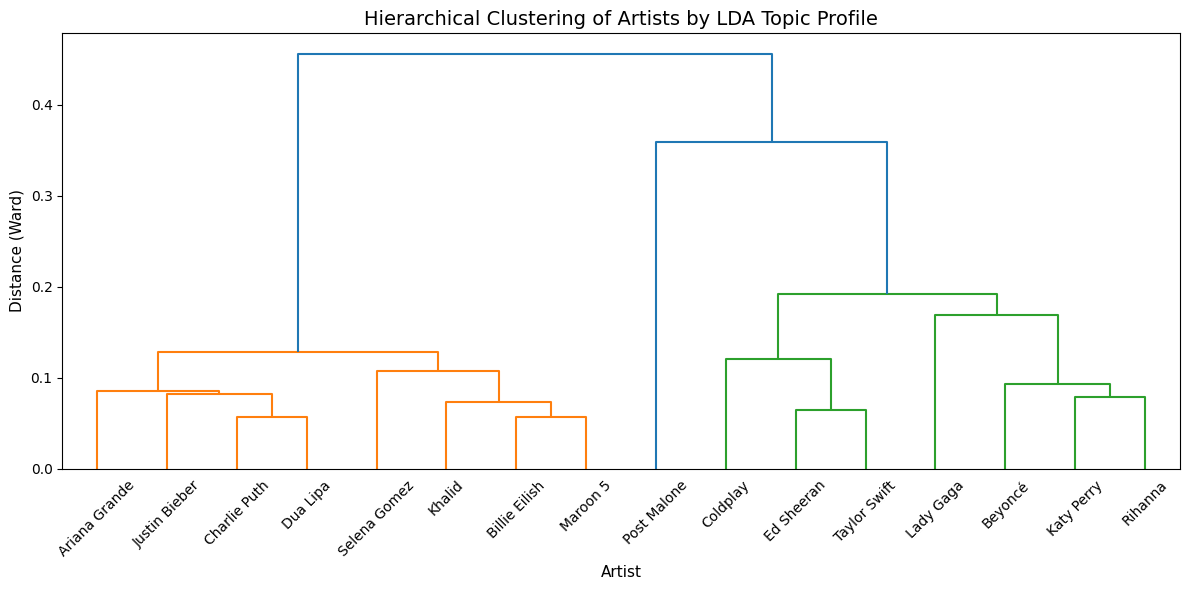

In [2]:
# Hierarchical Cluster Diagram of Artists by Topic Profile 
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import pdist

theta_lib = LDA_THETA.join(LIB.set_index('doc_id')[['artist']], how='left')
artist_topic = theta_lib.groupby('artist').mean()

# Compute linkage on artist topic profiles
linked = linkage(artist_topic.values, method='ward', metric='euclidean')

fig, ax = plt.subplots(figsize=(12, 6))
dendrogram(
    linked,
    labels=artist_topic.index.tolist(),
    orientation='top',
    leaf_rotation=45,
    leaf_font_size=10,
    color_threshold=0.6 * max(linked[:, 2]),
    ax=ax
)
ax.set_title('Hierarchical Clustering of Artists by LDA Topic Profile', fontsize=14)
ax.set_xlabel('Artist', fontsize=11)
ax.set_ylabel('Distance (Ward)', fontsize=11)
plt.tight_layout()
plt.savefig(OUTPUT_PATH + 'riff1_option_b_cluster.png', dpi=150, bbox_inches='tight')
plt.show()

# Riff 2

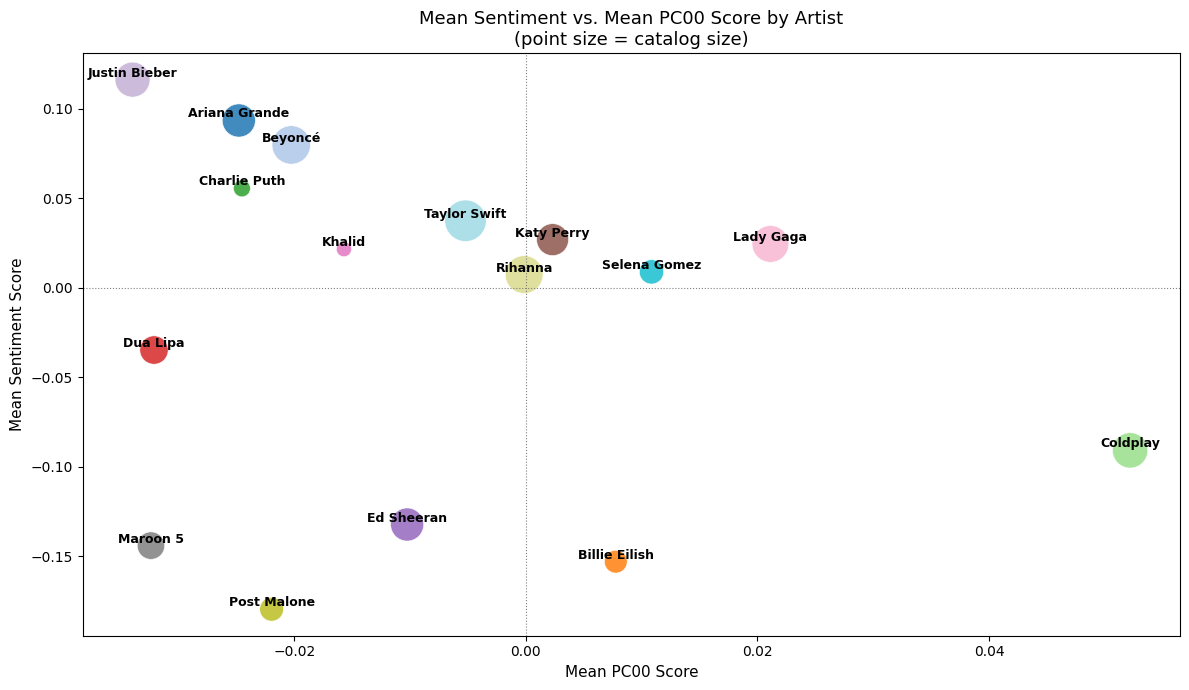

In [5]:
# Rebuild sent_pca (merge sentiment with PCA scores)
sent_pca = DOC_SENT[['doc_id', 'artist', 'sentiment_mean']].merge(
    PCA_DCM[['PC00', 'PC01']].reset_index(),
    on='doc_id', how='inner'
)
# Aggregate to artist level
artist_agg = sent_pca.groupby('artist').agg(
    pc00_mean=('PC00', 'mean'),
    sentiment_mean=('sentiment_mean', 'mean'),
    n_songs=('doc_id', 'count')
).reset_index()

fig, ax = plt.subplots(figsize=(12, 7))

scatter = ax.scatter(
    artist_agg['pc00_mean'],
    artist_agg['sentiment_mean'],
    s=artist_agg['n_songs'] * 2,  # size = catalog size
    c=range(len(artist_agg)),
    cmap='tab20',
    alpha=0.85,
    edgecolors='white',
    linewidth=0.5
)

# Label each point with artist name
for _, row in artist_agg.iterrows():
    ax.annotate(row['artist'], (row['pc00_mean'], row['sentiment_mean']),
                fontsize=9, ha='center', va='bottom', fontweight='bold')

ax.axhline(0, color='gray', linewidth=0.8, linestyle=':')
ax.axvline(0, color='gray', linewidth=0.8, linestyle=':')
ax.set_xlabel('Mean PC00 Score', fontsize=11)
ax.set_ylabel('Mean Sentiment Score', fontsize=11)
ax.set_title('Mean Sentiment vs. Mean PC00 Score by Artist\n(point size = catalog size)', fontsize=13)
plt.tight_layout()
plt.savefig(OUTPUT_PATH + 'riff2_sentiment_vs_pc00.png', dpi=150, bbox_inches='tight')
plt.show()

# Riff 3

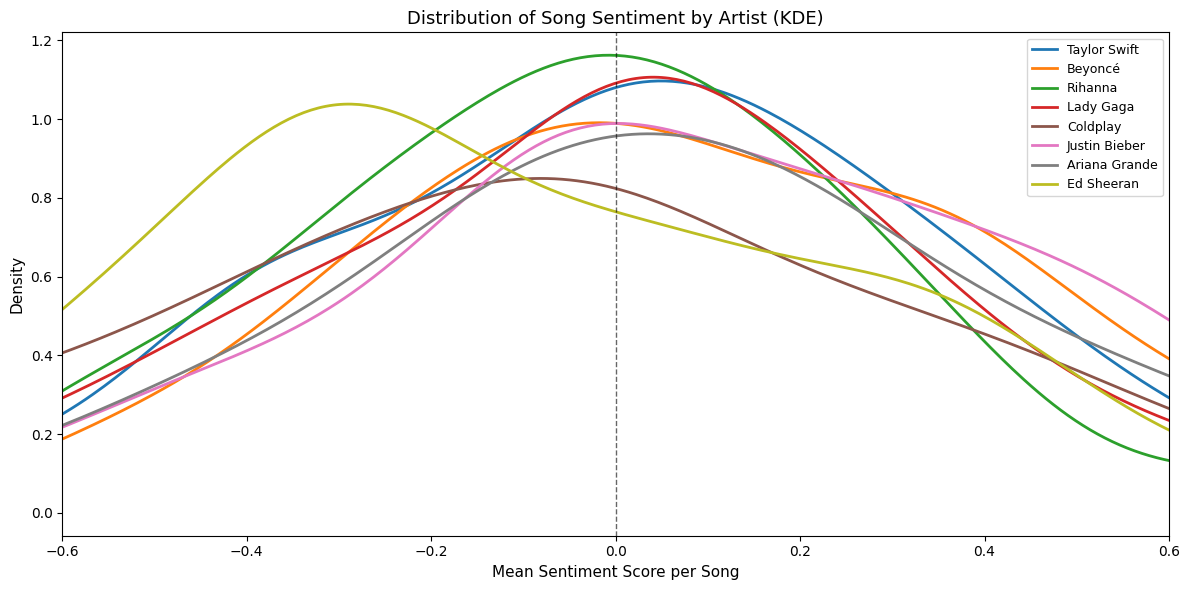

In [4]:
# Pick top 8 artists by song count for readability
top_artists = (
    DOC_SENT['artist'].value_counts()
    .head(8)
    .index.tolist()
)

fig, ax = plt.subplots(figsize=(12, 6))
palette = cm.tab10

for i, artist in enumerate(top_artists):
    data = DOC_SENT[DOC_SENT['artist'] == artist]['sentiment_mean'].dropna()
    data.plot.kde(ax=ax, label=artist, color=palette(i / len(top_artists)), linewidth=2)

ax.axvline(0, color='black', linewidth=1, linestyle='--', alpha=0.6)
ax.set_xlabel('Mean Sentiment Score per Song', fontsize=11)
ax.set_ylabel('Density', fontsize=11)
ax.set_title('Distribution of Song Sentiment by Artist (KDE)', fontsize=13)
ax.legend(fontsize=9, loc='upper right')
ax.set_xlim(-0.6, 0.6)
plt.tight_layout()
plt.savefig(OUTPUT_PATH + 'riff3_sentiment_kde.png', dpi=150, bbox_inches='tight')
plt.show()